In [21]:
!nvidia-smi

Mon Sep  8 13:02:07 2025       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 511.65       Driver Version: 511.65       CUDA Version: 11.6     |
|-------------------------------+----------------------+----------------------+
| GPU  Name            TCC/WDDM | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA GeForce ... WDDM  | 00000000:01:00.0  On |                  N/A |
| N/A   80C    P0   129W /  N/A |   5788MiB / 16384MiB |    100%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

### 파이토치의 대표적인 데이터셋을 이용하여 전이학습을 진행해보자

In [1]:
import os
import urllib.request
import zipfile
data_dir = "./data/"
if not os.path.exists(data_dir):
    os.mkdir(data_dir)
url = "https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json"
save_path = os.path.join(data_dir, "imagenet_class_index.json")

if not os.path.exists(save_path):
    urllib.request.urlretrieve(url, save_path)
url = "https://download.pytorch.org/tutorial/hymenoptera_data.zip"
save_path = os.path.join(data_dir, "hymenoptera_data.zip")

if not os.path.exists(save_path):
    urllib.request.urlretrieve(url, save_path)

    # ZIP 파일을 읽는다
    zip = zipfile.ZipFile(save_path)
    zip.extractall(data_dir)  # ZIP을 압축 해제
    zip.close()  # ZIP 파일을 닫는다

    # ZIP 파일을 삭제
    os.remove(save_path)


json 정렬은 alt+shift+F 임

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
import json

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils import data
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import utils, transforms, datasets, models
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [3]:
vgg16 = models.vgg16(pretrained=True)

c:\Users\devchoi\miniconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\devchoi\miniconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [4]:
class BaseTransform:
    def __init__(self, resize, mean, std):
        self.base_transform = transforms.Compose([
            transforms.Resize(resize), # 짧은변 기준 리사이즈
            transforms.CenterCrop(resize), # 이미지 중앙을 resize로 자르기
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ])

    def __call__(self, img):
        return self.base_transform(img)

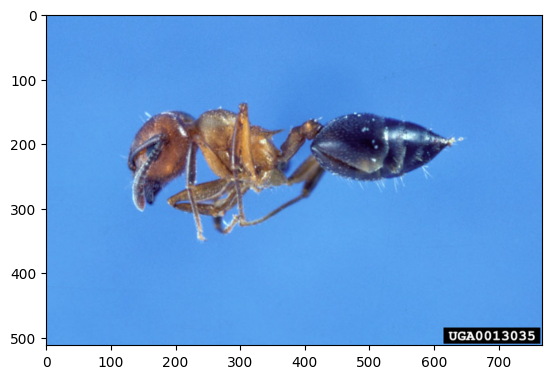

In [5]:
img_data = Image.open('data/hymenoptera_data/train/ants/0013035.jpg')
plt.imshow(img_data)
plt.show()

In [6]:
resize = 224
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
transform = BaseTransform(resize, mean, std)
img_tr = transform(img_data)

In [7]:
v_img_tr = img_tr.numpy().transpose((1,2,0))
v_img_tr.shape, img_tr.shape

((224, 224, 3), torch.Size([3, 224, 224]))

In [8]:
v_img_tr = np.clip(v_img_tr, 0, 1)

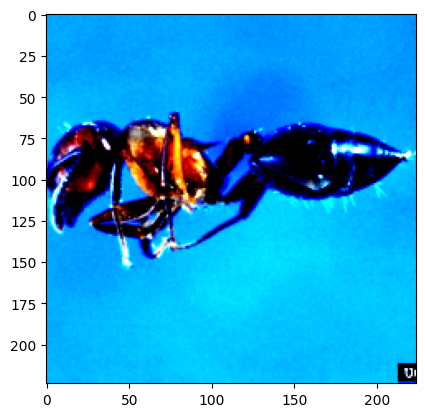

In [9]:
plt.imshow(v_img_tr)
plt.show()

In [10]:
ILSVRC_class_label=json.load(open('./data/imagenet_class_index.json','r'))
ILSVRC_class_label

{'0': ['n01440764', 'tench'],
 '1': ['n01443537', 'goldfish'],
 '2': ['n01484850', 'great_white_shark'],
 '3': ['n01491361', 'tiger_shark'],
 '4': ['n01494475', 'hammerhead'],
 '5': ['n01496331', 'electric_ray'],
 '6': ['n01498041', 'stingray'],
 '7': ['n01514668', 'cock'],
 '8': ['n01514859', 'hen'],
 '9': ['n01518878', 'ostrich'],
 '10': ['n01530575', 'brambling'],
 '11': ['n01531178', 'goldfinch'],
 '12': ['n01532829', 'house_finch'],
 '13': ['n01534433', 'junco'],
 '14': ['n01537544', 'indigo_bunting'],
 '15': ['n01558993', 'robin'],
 '16': ['n01560419', 'bulbul'],
 '17': ['n01580077', 'jay'],
 '18': ['n01582220', 'magpie'],
 '19': ['n01592084', 'chickadee'],
 '20': ['n01601694', 'water_ouzel'],
 '21': ['n01608432', 'kite'],
 '22': ['n01614925', 'bald_eagle'],
 '23': ['n01616318', 'vulture'],
 '24': ['n01622779', 'great_grey_owl'],
 '25': ['n01629819', 'European_fire_salamander'],
 '26': ['n01630670', 'common_newt'],
 '27': ['n01631663', 'eft'],
 '28': ['n01632458', 'spotted_salama

# 전이학습

In [11]:
class Make_dataset_Transform_tr:
    def __init__(self, resize, mean, std):
        self.base_transform = transforms.Compose([
                # 데이터 증강
                transforms.RandomResizedCrop(resize, scale=(0.5, 1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ])

    def __call__(self, img):
        return self.base_transform(img)

class Make_dataset_Transform_val:
    def __init__(self, resize, mean, std):
        self.base_transform = transforms.Compose([
                transforms.Resize(resize), # 짧은변 기준 리사이즈
                transforms.CenterCrop(resize), # 이미지 중앙을 resize로 자르기
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ])

    def __call__(self, img):
        return self.base_transform(img)

In [12]:
resize = 224
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
tr_base_transform = Make_dataset_Transform_tr(resize, mean, std)
val_base_transform = Make_dataset_Transform_tr(resize, mean, std)

In [13]:
import pathlib
basepath = pathlib.Path('./data/hymenoptera_data')
tr_ds = datasets.ImageFolder(basepath/'train', transform=tr_base_transform)
val_ds = datasets.ImageFolder(basepath/'val', transform=val_base_transform)

In [14]:
BATCH_SIZE = 32
tr_ds_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)
val_ds_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=True)

In [15]:
x, y = next(iter(tr_ds_loader))
x.shape, y.shape

(torch.Size([32, 3, 224, 224]), torch.Size([32]))

In [16]:
y

tensor([0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0,
        1, 0, 1, 1, 0, 0, 1, 1])

In [ ]:
class Make_dataset_Transform:
    def __init__(self,resize,mean,std):
        self.base_transform={
            'train':transforms.Compose([
                #데이터 증강
                transforms.RandomResizedCrop(resize,scale=(0.5,1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean,std)
            ]),
            'val':transforms.Compose([
            transforms.Resize(resize),#짧은변 기준 리사이즈
            transforms.CenterCrop(resize),#이미지 중앙을 resize 로 자르기           
            transforms.ToTensor(),
            transforms.Normalize(mean,std)
        ])
        }
    def __call__(self,img,phase='train'):
        return self.base_transform[phase](img)

In [18]:
import os.path as osp
import glob

def Make_data_path_list(root_path='./data/hymenoptera_data/', phase='train'):
    # len(root_path+phase) 
    target_path = osp.join(root_path+phase+'/**/*.jpg')
    out_list = []
    for path in glob.glob(target_path):
        out_list.append(path)
    return out_list
Make_data_path_list()

['./data/hymenoptera_data/train\\ants\\0013035.jpg',
 './data/hymenoptera_data/train\\ants\\1030023514_aad5c608f9.jpg',
 './data/hymenoptera_data/train\\ants\\1095476100_3906d8afde.jpg',
 './data/hymenoptera_data/train\\ants\\1099452230_d1949d3250.jpg',
 './data/hymenoptera_data/train\\ants\\116570827_e9c126745d.jpg',
 './data/hymenoptera_data/train\\ants\\1225872729_6f0856588f.jpg',
 './data/hymenoptera_data/train\\ants\\1262877379_64fcada201.jpg',
 './data/hymenoptera_data/train\\ants\\1269756697_0bce92cdab.jpg',
 './data/hymenoptera_data/train\\ants\\1286984635_5119e80de1.jpg',
 './data/hymenoptera_data/train\\ants\\132478121_2a430adea2.jpg',
 './data/hymenoptera_data/train\\ants\\1360291657_dc248c5eea.jpg',
 './data/hymenoptera_data/train\\ants\\1368913450_e146e2fb6d.jpg',
 './data/hymenoptera_data/train\\ants\\1473187633_63ccaacea6.jpg',
 './data/hymenoptera_data/train\\ants\\148715752_302c84f5a4.jpg',
 './data/hymenoptera_data/train\\ants\\1489674356_09d48dde0a.jpg',
 './data/hym

In [19]:
class Make_dataset(Dataset):
    def __init__(self, f_list, transform, phase='train'):
        self.f_list = f_list
        self.transform = transform
        self.phase = phase

    def __len__(self):
        return len(self.f_list)
    
    def __getitem__(self, index):
        img_path = self.f_list[index]
        img = Image.open(img_path)
        img_tr = self.transform(img, self.phase)
        if self.phase == 'train':
            label = img_path[30:34]
        elif self.phase == 'val':
            label = img_path[28:34]
        if label == 'ants':
            label = 0
        elif label == 'bees':
            label = 1
        return img_tr, label

# tr_ds = Make_dataset()

In [20]:
resize = 224
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
transform = Make_dataset_Transform(resize, mean, std)
basepath = './data/hymenoptera_data/'
tr_list = Make_data_path_list(basepath, 'train')
val_list = Make_data_path_list(basepath, 'val')
tr_ds = Make_dataset(tr_list, transform, 'train')
val_ds = Make_dataset(val_list, transform, 'val')

In [23]:
class Make_dataset_Transform:
    def __init__(self,resize,mean,std):
        self.base_transform={
            'train':transforms.Compose([
                #데이터 증강
                transforms.RandomResizedCrop(resize,scale=(0.5,1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean,std)
            ]),
            'val':transforms.Compose([
            transforms.Resize(resize),#짧은변 기준 리사이즈
            transforms.CenterCrop(resize),#이미지 중앙을 resize 로 자르기           
            transforms.ToTensor(),
            transforms.Normalize(mean,std)
        ])
        }
    def __call__(self,phase='train'):
        return self.base_transform[phase]

In [28]:
import pathlib

# 상수 정의
resize = 224
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
BATCH_SIZE = 32

# 데이터 로더 정의
transform = Make_dataset_Transform(resize, mean, std)
basepath = pathlib.Path('./data/hymenoptera_data/')
tr_ds = datasets.ImageFolder(basepath/'train', transform, 'train')
val_ds = datasets.ImageFolder(basepath/'val', transform, 'val')
tr_ds_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)
val_ds_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False) # val은 셔플을 하지 않는 것이 좋음

# 데이터 로드 구조 정리

In [ ]:
#0. 작업 준비
import numpy as np
import torch
import matplotlib.pyplot as plt
import json
from PIL import Image
import pathlib

from torch.utils import data
from torch.utils.data import Dataset,DataLoader,random_split
from torchvision import datasets,transforms, utils, models
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
USE_CUDA=torch.cuda.is_available()
DEVICE=torch.device('cuda' if USE_CUDA else 'cpu')

In [30]:
#데이터 로더 구조 정의
class Make_dataset_Transform:
    def __init__(self,resize,mean,std):
        self.base_transform={
            'train':transforms.Compose([
                #데이터 증강
                transforms.RandomResizedCrop(resize,scale=(0.5,1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean,std)
            ]),
            'val':transforms.Compose([
            transforms.Resize(resize),#짧은변 기준 리사이즈
            transforms.CenterCrop(resize),#이미지 중앙을 resize 로 자르기           
            transforms.ToTensor(),
            transforms.Normalize(mean,std)
        ])
        }
    def __call__(self,phase='train'):
        return self.base_transform[phase]

In [ ]:
#상수 정의
resize=224
'''
# 전체 데이터(모집합) 관점에서 평균 및 표준편차 도출하거나
# 데이터 전처리 방식에 따라 결정(예: [-1,1], mean, std = (0.5,0.5,0.5), (0.5,0.5,0.5))
# 전이학습을 활용한다면 가급적 사용 모델의 표준화를 사용할 것
반드시 채널 단위 연산을 진행해야 됨
'''
mean=(0.485,0.456,0.406) # 이미지넷 데이터의 표준화값
std=(0.229,0.224,0.225) # 이미지넷 데이터의 표준화값
BATCH_SIZE=32

#데이터 로더 정의
transform=Make_dataset_Transform(resize,mean,std)
basepath=pathlib.Path('./data/hymenoptera_data')
tr_ds=datasets.ImageFolder(basepath/'train',transform=transform('train'))
val_ds=datasets.ImageFolder(basepath/'val',transform=transform('val'))
tr_ds_loader=DataLoader(tr_ds,batch_size=BATCH_SIZE,shuffle=True)
val_ds_loader=DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False)

In [33]:
tr_x, tr_y = next(iter(tr_ds_loader))
val_x, val_y = next(iter(val_ds_loader))
tr_x.shape, val_x.shape

(torch.Size([32, 3, 224, 224]), torch.Size([32, 3, 224, 224]))

In [34]:
tr_y

tensor([0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0,
        1, 0, 1, 0, 1, 1, 1, 1])

In [36]:
[y for x,y in val_ds_loader][::-1]

[tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1]),
 tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1]),
 tensor([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1]),
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0]),
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0])]

In [39]:
from torchvision.models import vgg16, VGG16_Weights # 가중치는 필드로 담겨있기 때문에 클래스로 구성된 가중치임
# model = vgg16(pretrained=True) # 옛날 방식
vgg16_m = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
vgg16_m

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [49]:
vgg16_m.features.parameters

<bound method Module.parameters of Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)

In [42]:
for p in vgg16_m.features.parameters():
    p.requires_grad = False # 파라미터를 고정

In [ ]:
# 분류기층의 마지막
class_n = 2
clf_in_n = vgg16_m.classifier[-1].in_features # 분류층의 입력 뉴런
vgg16_m.classifier[-1] = nn.Linear(clf_in_n, class_n) # 실무에선 종단만 고쳐서 쓰는 경우가 많음
# 데이터가 적을 땐 종단만 수정하는 것이 효율적임

In [47]:
vgg16_m

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [48]:
vgg16_m = vgg16_m.to(DEVICE)
criterion = nn.CrossEntropyLoss()
opt = optim.Adam(filter(lambda p: p.requires_grad, vgg16_m.parameters()), lr=1e-4)

In [50]:
def run_epoch(m, loader, train=True):
    m.train(train)
    total_loss, total_correct, total = 0.0, 0, 0
    for x,y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        if train:
            opt.zero_grad()
        with torch.set_grad_enabled(train): # torch.no_grad()의 다른 방식임
            output = m(x)
            loss = criterion(output, y)
            if train:
                loss.backward()
                opt.step()
        total_loss += loss.item() * x.size(0)
        total_correct += ((output.argmax(1)==y).sum().item())
        total += x.size(0)
    return total_loss/total, total_correct/total

tr_losses = []
tr_loss, tr_acc = run_epoch(vgg16_m, tr_ds_loader, True)
val_loss, val_acc = run_epoch(vgg16_m, val_ds_loader, False)
print(f'tr_loss: {tr_loss:.4f}, tr_acc: {tr_acc:.4f} | val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}')

tr_loss: 0.3195, tr_acc: 0.8648 | val_loss: 0.1541, val_acc: 0.9477


# 개 종 분류기를 전이학습을 이용해 학습하시오. 단 학습 횟수는 3회
https://www.kaggle.com/datasets/jessicali9530/stanford-dogs-dataset

In [75]:
#0. 작업 준비
import numpy as np
import torch
import matplotlib.pyplot as plt
import json
from PIL import Image
import pathlib
from glob import glob

from torch.utils import data
from torch.utils.data import Dataset,DataLoader,random_split
from torchvision import datasets,transforms, utils, models
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
USE_CUDA=torch.cuda.is_available()
DEVICE=torch.device('cuda' if USE_CUDA else 'cpu')

In [188]:
#데이터 로더 구조 정의
class Dataset_Transform:
    def __init__(self,resize,mean,std):
        self.base_transform={
            'train':transforms.Compose([ #데이터 증강
                transforms.RandomResizedCrop(resize,scale=(0.5,1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean,std)
            ]),
            'val':transforms.Compose([
                transforms.Resize(resize),#짧은변 기준 리사이즈
                transforms.CenterCrop(resize),#이미지 중앙을 resize 로 자르기           
                transforms.ToTensor(),
                transforms.Normalize(mean,std)
            ])
        }
    def __call__(self,phase='train'):
        return self.base_transform[phase]

In [189]:
class DatasetLoad(Dataset):
    def __init__(self, path, transform=None):
        self.path = path
        self.classes = glob(path)
        self.imgs = glob(path+'/*.jpg')
        self.transform = transform
        self.label_dict = {c.split('-',1)[-1].lower(): i for i, c in enumerate(glob(self.path))}

    def __len__(self):
        return len(self.imgs)
    
    def __getitem__(self,idx):
        o_img = self.imgs[idx]
        img = Image.open(o_img).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = o_img.split('-', 1)[1].split('\\')[0].lower()
        label_num = -1
        if self.label_dict[label] >= 0:
            label_num = self.label_dict[label]
        else:
            raise ValueError(f'데이터의 클래스를 확인할 수 없습니다.{o_img.name}')
        return img, label_num

In [190]:
class WrappingTransform(Dataset):
    def __init__(self, subnet, transform):
        self.subnet = subnet
        self.transform = transform

    def __len__(self):
        return len(self.subnet)
    
    def __getitem__(self,idx):
        img, label = self.subnet[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

In [201]:
RESIZE=224
MEAN=(0.485,0.456,0.406) 
STD=(0.229,0.224,0.225)
BATCH_SIZE=64
PATH = 'data/images/images/*'

In [202]:
transform = Dataset_Transform(resize,mean,std)
# datasetload = DatasetLoad(PATH, transform=transform('train'))
datasetload = DatasetLoad(PATH)
tr_ds_n, val_ds_n = map(int, [datasetload.__len__()*0.8, datasetload.__len__()*0.2])
tr_ds, val_ds = random_split(datasetload, [tr_ds_n, val_ds_n])

In [203]:
tr_ds = WrappingTransform(tr_ds, transform=transform('train'))
val_ds = WrappingTransform(val_ds, transform=transform('val'))
print(len(tr_ds), len(val_ds))
tr_ds_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)
val_ds_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=True)

16464 4116


In [204]:
tr_x, tr_y = next(iter(tr_ds_loader))
val_x, val_y = next(iter(val_ds_loader))
tr_x.shape, val_x.shape

(torch.Size([64, 3, 224, 224]), torch.Size([64, 3, 224, 224]))

In [205]:
model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [206]:
for p in model.features.parameters():
    p.requires_grad = False # 파라미터를 고정

In [207]:
len(datasetload.classes)

120

In [208]:
class_n = len(datasetload.classes)
clf_in_n = vgg16_m.classifier[-1].in_features 
vgg16_m.classifier[-1] = nn.Linear(clf_in_n, class_n) 

In [209]:
vgg16_m = vgg16_m.to(DEVICE)
criterion = nn.CrossEntropyLoss()
opt = optim.Adam(filter(lambda p: p.requires_grad, vgg16_m.parameters()), lr=1e-4)

데이터 전처리 수정본으로 진행

In [210]:
from tqdm import tqdm
def run_epoch(m, loader, train=True):
    m.train(train)
    total_loss, total_correct, total = 0.0, 0, 0
    for x,y in tqdm(loader):
        x, y = x.to(DEVICE), y.to(DEVICE)
        if train:
            opt.zero_grad()
        with torch.set_grad_enabled(train): # torch.no_grad()의 다른 방식임
            output = m(x)
            loss = criterion(output, y)
            if train:
                loss.backward()
                opt.step()
        total_loss += loss.item() * x.size(0)
        total_correct += ((output.argmax(1)==y).sum().item())
        total += x.size(0)
    return total_loss/total, total_correct/total


for i in range(5):
    tr_loss, tr_acc = run_epoch(vgg16_m, tr_ds_loader, True)
    val_loss, val_acc = run_epoch(vgg16_m, val_ds_loader, False)
    print(f'tr_loss: {tr_loss:.4f}, tr_acc: {tr_acc:.4f} | val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}')

100%|██████████| 65/65 [00:23<00:00,  2.79it/s]


tr_loss: 1.3620, tr_acc: 0.6356 | val_loss: 0.4005, val_acc: 0.8812


100%|██████████| 65/65 [00:22<00:00,  2.86it/s]


tr_loss: 0.6169, tr_acc: 0.8096 | val_loss: 0.3682, val_acc: 0.8882


100%|██████████| 65/65 [00:22<00:00,  2.88it/s]


tr_loss: 0.5145, tr_acc: 0.8384 | val_loss: 0.3705, val_acc: 0.8868


100%|██████████| 65/65 [00:22<00:00,  2.87it/s]


tr_loss: 0.4484, tr_acc: 0.8575 | val_loss: 0.3761, val_acc: 0.8807


100%|██████████| 65/65 [00:23<00:00,  2.80it/s]

tr_loss: 0.4020, tr_acc: 0.8738 | val_loss: 0.3603, val_acc: 0.8853


위 코드는 loss값은 내려가긴 했는데 val acc가 변동이 거의 없음;;

아래는 파라미터 고정 안하고 학습 진행

In [180]:
from tqdm import tqdm
def run_epoch(m, loader, train=True):
    m.train(train)
    total_loss, total_correct, total = 0.0, 0, 0
    for x,y in tqdm(loader):
        x, y = x.to(DEVICE), y.to(DEVICE)
        if train:
            opt.zero_grad()
        with torch.set_grad_enabled(train): # torch.no_grad()의 다른 방식임
            output = m(x)
            loss = criterion(output, y)
            if train:
                loss.backward()
                opt.step()
        total_loss += loss.item() * x.size(0)
        total_correct += ((output.argmax(1)==y).sum().item())
        total += x.size(0)
    return total_loss/total, total_correct/total


for i in range(3):
    tr_loss, tr_acc = run_epoch(vgg16_m, tr_ds_loader, True)
    val_loss, val_acc = run_epoch(vgg16_m, val_ds_loader, False)
    print(f'tr_loss: {tr_loss:.4f}, tr_acc: {tr_acc:.4f} | val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}')

100%|██████████| 65/65 [00:21<00:00,  3.02it/s]


tr_loss: 0.8858, tr_acc: 0.7317 | val_loss: 0.6982, val_acc: 0.7843


100%|██████████| 65/65 [00:21<00:00,  3.00it/s]


tr_loss: 0.7017, tr_acc: 0.7786 | val_loss: 0.6766, val_acc: 0.7979


100%|██████████| 65/65 [00:21<00:00,  3.01it/s]

tr_loss: 0.5973, tr_acc: 0.8113 | val_loss: 0.6712, val_acc: 0.7993


아래는 파라미터 고정후 학습 진행

In [186]:
from tqdm import tqdm
def run_epoch(m, loader, train=True):
    m.train(train)
    total_loss, total_correct, total = 0.0, 0, 0
    for x,y in tqdm(loader):
        x, y = x.to(DEVICE), y.to(DEVICE)
        if train:
            opt.zero_grad()
        with torch.set_grad_enabled(train): # torch.no_grad()의 다른 방식임
            output = m(x)
            loss = criterion(output, y)
            if train:
                loss.backward()
                opt.step()
        total_loss += loss.item() * x.size(0)
        total_correct += ((output.argmax(1)==y).sum().item())
        total += x.size(0)
    return total_loss/total, total_correct/total


for i in range(3):
    tr_loss, tr_acc = run_epoch(vgg16_m, tr_ds_loader, True)
    val_loss, val_acc = run_epoch(vgg16_m, val_ds_loader, False)
    print(f'tr_loss: {tr_loss:.4f}, tr_acc: {tr_acc:.4f} | val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}')

100%|██████████| 65/65 [00:21<00:00,  2.96it/s]


tr_loss: 1.4359, tr_acc: 0.6150 | val_loss: 0.7549, val_acc: 0.7665


100%|██████████| 65/65 [00:21<00:00,  2.98it/s]


tr_loss: 0.7167, tr_acc: 0.7790 | val_loss: 0.6916, val_acc: 0.7896


100%|██████████| 65/65 [00:21<00:00,  2.97it/s]

tr_loss: 0.5771, tr_acc: 0.8157 | val_loss: 0.6859, val_acc: 0.7949


위 코드에서 연속진행

In [187]:
for i in range(3):
    tr_loss, tr_acc = run_epoch(vgg16_m, tr_ds_loader, True)
    val_loss, val_acc = run_epoch(vgg16_m, val_ds_loader, False)
    print(f'tr_loss: {tr_loss:.4f}, tr_acc: {tr_acc:.4f} | val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}')

100%|██████████| 65/65 [00:22<00:00,  2.95it/s]


tr_loss: 0.5063, tr_acc: 0.8399 | val_loss: 0.6674, val_acc: 0.7928


100%|██████████| 65/65 [00:22<00:00,  2.92it/s]


tr_loss: 0.4569, tr_acc: 0.8533 | val_loss: 0.7001, val_acc: 0.7879


100%|██████████| 65/65 [00:22<00:00,  2.91it/s]

tr_loss: 0.4210, tr_acc: 0.8617 | val_loss: 0.7148, val_acc: 0.7915
